# Comparing Groups: T-test and ANOVA

**Dataset:** `ads_data.csv` — Digital advertising events (views and clicks)

**Topics:**
1. Z-score vs T-score — known vs unknown population parameters
2. T-distribution — heavier tails and degrees of freedom
3. Dataset overview and CTR aggregation
4. Log transformation for skewed distributions
5. Two-group comparison — T-test (CPC vs CPM ad types)
6. Multi-group comparison — One-way ANOVA (platforms)

## Dataset Description

| Column | Type | Description |
|--------|------|-------------|
| `ad_id` | int | Unique ad identifier |
| `time` | int | Unix timestamp of the event |
| `event` | str | Event type: `view` or `click` |
| `date` | datetime | Date of the event |
| `ad_cost_type` | str | Pricing model: `CPC` (cost-per-click) or `CPM` (cost-per-mille) |
| `has_video` | int | Whether the ad contains a video (0/1) |
| `client_union_id` | int | Advertiser identifier |
| `campaign_union_id` | int | Campaign identifier |
| `platform` | str | Platform: `android`, `ios`, or `web` |
| `ad_cost` | float | Cost of the ad placement |
| `target_audience_count` | int | Size of the target audience |
| `user_id` | int | User who saw or clicked the ad |

In [152]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, f_oneway

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 1. Z-score vs T-score

When estimating a population mean from a sample, the statistic we use depends on what we know:

| Scenario | Statistic | Formula | Distribution |
|----------|-----------|---------|-------------|
| Population σ **known** | Z-score | $z = \dfrac{\bar{x} - \mu}{\sigma / \sqrt{n}}$ | Standard normal $\mathcal{N}(0,1)$ |
| Population σ **unknown** | T-score | $t = \dfrac{\bar{x} - \mu}{s / \sqrt{n}}$ | Student's t with $n-1$ df |

When σ is unknown, we substitute the sample standard deviation $s$, which introduces extra uncertainty.  
The **T-distribution** accounts for this — it has heavier tails than the normal distribution,  
especially for small samples. As $n \to \infty$, the T-distribution converges to $\mathcal{N}(0,1)$.

> **Rule of thumb:** For $n > 30$, the T-distribution is close enough to normal that the distinction rarely matters.

In [153]:
# Simulate a known population
mu, sigma = 100, 10
population = np.random.normal(mu, sigma, 10_000).round(2)

print(f'Population mean: {population.mean():.2f}')
print(f'Population std:  {population.std():.2f}')

Population mean: 99.98
Population std:  10.03


In [154]:
# Z-scores: use known population sigma
sample_size = 30
se = sigma / np.sqrt(sample_size)  # standard error (known sigma)
n_samples = 1000

sample_means, z_scores = [], []
for _ in range(n_samples):
    s_mean = np.random.choice(population, sample_size, replace=False).mean()
    z_scores.append((s_mean - mu) / se)
    sample_means.append(s_mean)

In [155]:
# T-scores: estimate sigma from each sample
t_scores = []
for _ in range(n_samples):
    sample = np.random.choice(population, sample_size, replace=False)
    se_hat = sample.std() / np.sqrt(sample_size)  # estimated SE
    t_scores.append((sample.mean() - mu) / se_hat)

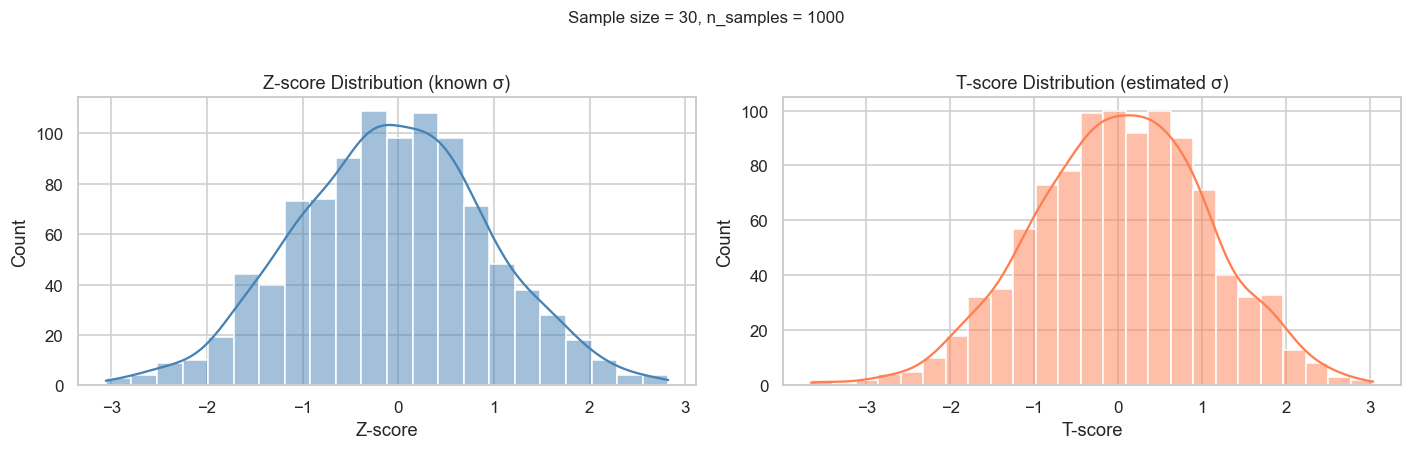

Degrees of freedom: n - 1 = 29


In [156]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(z_scores, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Z-score Distribution (known σ)')
axes[0].set_xlabel('Z-score')

sns.histplot(t_scores, kde=True, ax=axes[1], color='coral')
axes[1].set_title('T-score Distribution (estimated σ)')
axes[1].set_xlabel('T-score')

plt.suptitle(f'Sample size = {sample_size}, n_samples = {n_samples}', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# The T-distribution has heavier tails — estimating sigma adds extra variability
df = sample_size - 1
print(f'Degrees of freedom: n - 1 = {df}')

## 2. Dataset Overview

The raw dataset records individual ad events — one row per view or click.  
We aggregate into per-ad statistics to compute **CTR** (Click-Through Rate):

$$CTR = \frac{\text{Clicks}}{\text{Views}}$$

Higher CTR → the ad is more relevant or engaging to its target audience.

In [158]:
ads = pd.read_csv('ads_data.csv', parse_dates=['date'])
print(f'Shape: {ads.shape}')
ads.head()

Shape: (3176714, 12)


,ad_id,time,event,date,ad_cost_type,has_video,client_union_id,campaign_union_id,platform,ad_cost,target_audience_count,user_id
0,23456,1554076848,view,2019-04-01,CPM,0,5681,23456,android,190.0,125560,793
1,111941,1554135866,view,2019-04-01,CPM,0,111793,111941,ios,215.2,32277,1041
2,111941,1554135866,view,2019-04-01,CPM,0,111793,111941,ios,215.2,32277,41
3,42987,1554135866,view,2019-04-01,CPM,0,28541,42985,ios,199.1,80160,898
4,23456,1554135866,view,2019-04-01,CPM,0,5681,23456,web,190.0,125560,29


In [159]:
print('Unique values per column:')
ads.apply(lambda x: x.nunique()).sort_values()

Unique values per column:


event                        2
ad_cost_type                 2
has_video                    2
platform                     3
date                         6
ad_cost                    252
client_union_id            336
campaign_union_id          349
target_audience_count      352
ad_id                      355
user_id                   8490
time                     25235
dtype: int64

In [160]:
ads.info()

<class 'pandas.DataFrame'>
RangeIndex: 3176714 entries, 0 to 3176713
Data columns (total 12 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   ad_id                  int64         
 1   time                   int64         
 2   event                  str           
 3   date                   datetime64[us]
 4   ad_cost_type           str           
 5   has_video              int64         
 6   client_union_id        int64         
 7   campaign_union_id      int64         
 8   platform               str           
 9   ad_cost                float64       
 10  target_audience_count  int64         
 11  user_id                int64         
dtypes: datetime64[us](1), float64(1), int64(7), str(3)
memory usage: 290.8 MB


## 3. Aggregate CTR by Ad Type and Platform

Pivot the event-level data to get clicks and views per `(ad_id, ad_cost_type, platform)`,  
then filter to ads with sufficient traffic to reduce noise:
- At least **100 views** (statistical stability)
- At least **1 click** (avoid log(0) = −∞ after log-transformation)

In [161]:
# Pivot: count users per (ad_id, ad_cost_type, platform, event)
df = (
    ads
    .groupby(['ad_id', 'ad_cost_type', 'platform', 'event'], as_index=False)
    .agg({'user_id': 'count'})
    .pivot(index=['ad_id', 'ad_cost_type', 'platform'], columns='event', values='user_id')
    .reset_index()
)
df.head()

event,ad_id,ad_cost_type,platform,click,view
0,3,CPC,android,5.0,244.0
1,3,CPC,ios,3.0,147.0
2,3,CPC,web,1.0,99.0
3,2132,CPC,android,1.0,55.0
4,2132,CPC,ios,NaN,26.0


In [162]:
# Aggregate by ad_id + ad_cost_type (collapse platforms)
cost_type_df = (
    df
    .groupby(['ad_id', 'ad_cost_type'], as_index=False)
    .agg({'click': 'sum', 'view': 'sum'})
    .query('view >= 100 & click >= 1')
    .assign(ctr=lambda d: d.click / d.view)
)
cost_type_df.head()

event,ad_id,ad_cost_type,click,view,ctr
0,3,CPC,9.0,490.0,0.018367
2,2276,CPC,2.0,1454.0,0.001376
4,2643,CPM,3.0,286.0,0.010490
5,4585,CPC,53.0,476.0,0.111345
6,4877,CPC,5.0,2160.0,0.002315


In [163]:
print('CTR by ad cost type:')
cost_type_df.groupby('ad_cost_type')['ctr'].describe().round(4)

CTR by ad cost type:


,count,mean,std,min,25%,50%,75%,max
ad_cost_type,,,,,,,,
CPC,55.0,0.0241,0.03,0.0009,0.0076,0.0120,0.0330,0.1673
CPM,247.0,0.0195,0.03,0.0005,0.0052,0.0105,0.0226,0.3000


/var/folders/xf/ygl5_zk57kn1rh2h1xj9fyx40000gn/T/ipykernel_9340/177168204.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ad_cost_type', y='ctr', data=cost_type_df, palette='Set2', ax=axes[0])


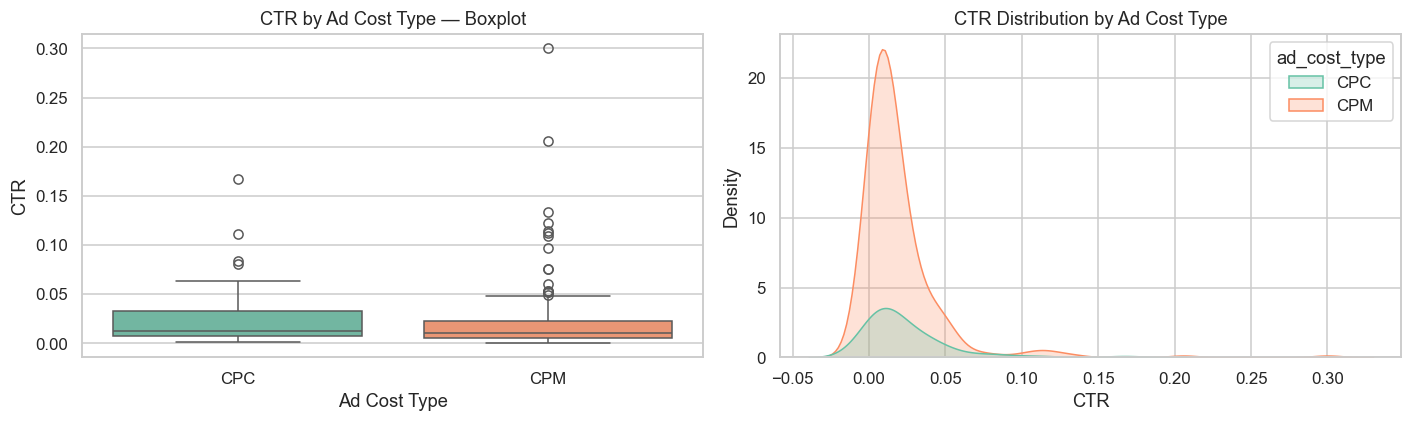

In [164]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(x='ad_cost_type', y='ctr', data=cost_type_df, palette='Set2', ax=axes[0])
axes[0].set_title('CTR by Ad Cost Type — Boxplot')
axes[0].set_xlabel('Ad Cost Type')
axes[0].set_ylabel('CTR')

sns.kdeplot(data=cost_type_df, x='ctr', hue='ad_cost_type', fill=True, palette='Set2', ax=axes[1])
axes[1].set_title('CTR Distribution by Ad Cost Type')
axes[1].set_xlabel('CTR')

plt.tight_layout()
plt.show()

# Both groups show strong right skew — raw CTR is not suitable for a t-test

## 4. Log Transformation for Skewed Distributions

The T-test assumes **approximately normal** distributions. CTR is heavily right-skewed — a few ads have  
very high CTR while most cluster near zero. Applying a **log transform** compresses large values  
and makes the distribution more symmetric:

$$CTR_{\log} = \ln(CTR)$$

**Why log works:** the natural log penalizes large values more than small ones.

| x | ln(x) |
|---|-------|
| 1 | 0.0 |
| 10 | 2.3 |
| 100 | 4.6 |
| 10 000 | 9.2 |

A distribution where $\ln(x)$ is approximately normal is called **log-normal** —  
common in click rates, prices, and many other industry metrics.

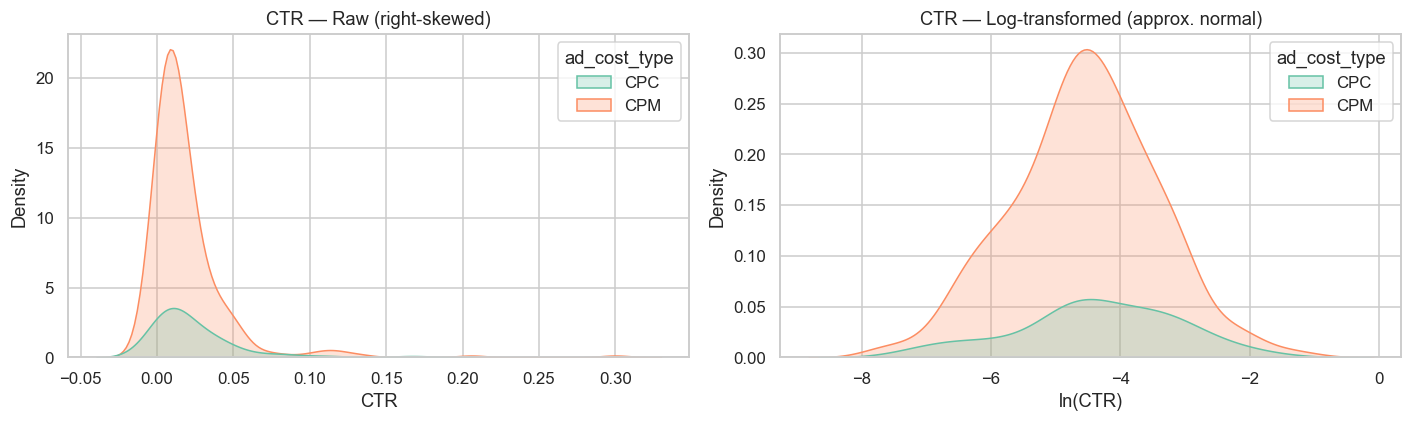

In [165]:
cost_type_df = cost_type_df.assign(ctr_log=lambda d: np.log(d.ctr))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.kdeplot(data=cost_type_df, x='ctr', hue='ad_cost_type', fill=True, palette='Set2', ax=axes[0])
axes[0].set_title('CTR — Raw (right-skewed)')
axes[0].set_xlabel('CTR')

sns.kdeplot(data=cost_type_df, x='ctr_log', hue='ad_cost_type', fill=True, palette='Set2', ax=axes[1])
axes[1].set_title('CTR — Log-transformed (approx. normal)')
axes[1].set_xlabel('ln(CTR)')

plt.tight_layout()
plt.show()

## 5. Two-Group Comparison — T-test

**Research question:** Do CPC and CPM ads have significantly different CTRs?

**Hypotheses:**
- $H_0$: The mean log-CTR is equal for CPC and CPM ads
- $H_1$: The mean log-CTR differs between CPC and CPM ads

We use **Welch's T-test** (`equal_var=False` default in scipy), which does not assume  
equal variances across groups — the safer choice when group sizes differ.

In [166]:
cpc_log = cost_type_df.query('ad_cost_type == "CPC"')['ctr_log']
cpm_log = cost_type_df.query('ad_cost_type == "CPM"')['ctr_log']

result = ttest_ind(cpc_log, cpm_log)
print(f'T-statistic: {result.statistic:.4f}')
print(f'P-value:     {result.pvalue:.4f}')
print()
alpha = 0.05
if result.pvalue < alpha:
    print(f'p < {alpha} → Reject H₀: CTR differs significantly between CPC and CPM')
else:
    print(f'p = {result.pvalue:.2f} > {alpha} → Fail to reject H₀: no significant CTR difference')
    print('A 25% chance of seeing such differences under H₀ is not unusual — not enough evidence.')

T-statistic: 1.1407
P-value:     0.2549

p = 0.25 > 0.05 → Fail to reject H₀: no significant CTR difference
A 25% chance of seeing such differences under H₀ is not unusual — not enough evidence.


## 6. Multi-Group Comparison — One-Way ANOVA

**Research question:** Does CTR differ across platforms (android, ios, web)?

With more than two groups, we use **ANOVA** (Analysis of Variance):  
- $H_0$: All group means are equal — $\mu_{android} = \mu_{ios} = \mu_{web}$
- $H_1$: At least one group mean differs from the others

The **F-statistic** compares between-group variance to within-group variance:

$$F = \frac{\text{between-group variance}}{\text{within-group variance}}$$

A large F (small p-value) means the group differences are unlikely due to chance.

In [167]:
platform_df = (
    df
    .groupby(['ad_id', 'platform'], as_index=False)
    .agg({'click': 'sum', 'view': 'sum'})
    .fillna(0)
    .query('view > 100 & click > 0')
    .assign(
        ctr=lambda d: d.click / d.view,
        ctr_log=lambda d: np.log(d.click / d.view)
    )
)
platform_df.head()

event,ad_id,platform,click,view,ctr,ctr_log
0,3,android,5.0,244.0,0.020492,-3.887730
1,3,ios,3.0,147.0,0.020408,-3.891820
6,2276,android,2.0,703.0,0.002845,-5.862210
15,4585,android,17.0,224.0,0.075893,-2.578433
16,4585,ios,24.0,148.0,0.162162,-1.819158


CTR by platform:
          count    mean     std     min     25%     50%     75%     max
platform                                                               
android   233.0  0.0208  0.0317  0.0005  0.0054  0.0107  0.0246  0.2990
ios       182.0  0.0208  0.0350  0.0009  0.0052  0.0096  0.0233  0.3015
web       137.0  0.0216  0.0352  0.0006  0.0059  0.0112  0.0234  0.3002


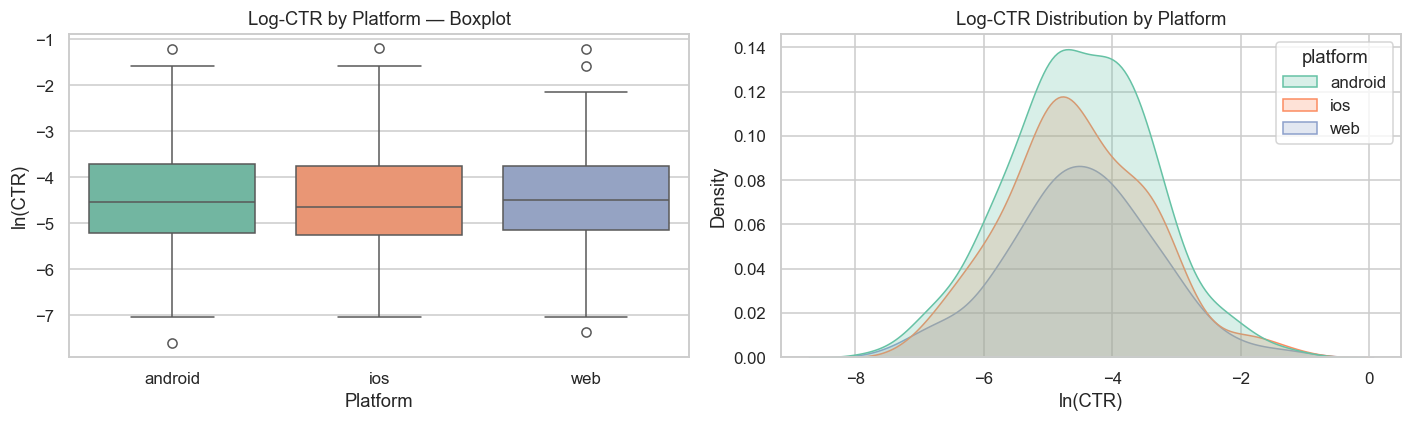

In [169]:
print('CTR by platform:')
print(platform_df.groupby('platform')['ctr'].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(x='platform', y='ctr_log', hue='platform', data=platform_df,
            palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Log-CTR by Platform — Boxplot')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('ln(CTR)')

sns.kdeplot(data=platform_df, x='ctr_log', hue='platform', fill=True, palette='Set2', ax=axes[1])
axes[1].set_title('Log-CTR Distribution by Platform')
axes[1].set_xlabel('ln(CTR)')

plt.tight_layout()
plt.show()

In [170]:
android_log = platform_df.query('platform == "android"')['ctr_log']
ios_log     = platform_df.query('platform == "ios"')['ctr_log']
web_log     = platform_df.query('platform == "web"')['ctr_log']

result = f_oneway(android_log, ios_log, web_log)
print(f'F-statistic: {result.statistic:.4f}')
print(f'P-value:     {result.pvalue:.4f}')
print()
alpha = 0.05
if result.pvalue < alpha:
    print(f'p < {alpha} → Reject H₀: at least one platform has a different CTR')
else:
    print(f'p = {result.pvalue:.4f} > {alpha} → Fail to reject H₀: no significant CTR difference across platforms')

F-statistic: 0.1222
P-value:     0.8850

p = 0.8850 > 0.05 → Fail to reject H₀: no significant CTR difference across platforms
